# Optimizer and Objective Interventions

## Group C: how training selects a solution

This notebook investigates whether the baseline fails because the objective or training procedure is selecting a poor solution. Data sampling, input variables, and model family remain fixed.

By the end of this notebook you should be able to:

- distinguish an optimizer/objective intervention from a data or hypothesis-space intervention;
- use training curves and validation evidence to argue for or against a failure hypothesis;
- choose one training-procedure change without using the test set as a search tool;
- record a concise experiment result that your group can report back.

**Activity contract**

| Category | Rule |
|---|---|
| Fixed | Data rows, inputs, MLP width/depth/activation, evaluation report |
| Allowed | Scaling, initialization, seed set, learning rate, batch size, epochs, objective/loss |
| Not allowed | Adding variables, changing data collection, changing split strategy, changing model capacity |
| Selection rule | Choose interventions using validation evidence |
| Test rule | Use test performance only after the choice is fixed |

Keep `show_advanced=False` unless an extension is explicitly enabled.

**Reasoning loop for every subsection**

$$
H_{\mathrm{fail}}
\xrightarrow{E}
I_E
\xrightarrow{\Delta}
H_{\Delta}
\xrightarrow{\mathcal{E}}
R
\xrightarrow{J}
C.
$$

Here $H_{\mathrm{fail}}$ is the failure hypothesis, $E$ is evidence, $I_E$ is the interpretation of that evidence, $\Delta$ is the intervention design, $H_{\Delta}$ is the intervention hypothesis, $\mathcal{E}$ is the experiment, $R$ is the result, $J$ is the evaluation judgement, and $C$ is the conclusion or discussion claim.

Use the result log in each subsection to capture what you tried, what happened, and what you concluded. The goal is not to run a broad hyperparameter search; the goal is to run controlled tests of training explanations.


## Activity Note

Some comparison cells intentionally contain `...` placeholders. Replace those placeholders with the scaling, schedule, or objective options your group wants to test before running that evidence cell. The instructor copy contains a calibrated runnable path.


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

REPO_URL = "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git"
REPO_BRANCH = "workshop3"
PACKAGE_NAME = "nextgen2026_mlai_workshops"

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                REPO_BRANCH,
                REPO_URL,
                str(repo_dir),
            ],
            check=True,
        )
    else:
        subprocess.run(["git", "-C", str(repo_dir), "fetch", "--depth", "1", "origin", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(repo_dir), "checkout", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only", "origin", REPO_BRANCH], check=True)

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    missing_packages = [
        package_name
        for package_name, module_name in (("pandas", "pandas"), ("torch", "torch"))
        if importlib.util.find_spec(module_name) is None
    ]
    if missing_packages:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing_packages], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    repo_dir = None
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / PACKAGE_NAME).exists():
            repo_dir = possible_root
            sys.path.insert(0, str(possible_src))
            break

for module_name in list(sys.modules):
    if module_name == PACKAGE_NAME or module_name.startswith(f"{PACKAGE_NAME}."):
        del sys.modules[module_name]

print(f"Workshop 3 environment ready. Repository: {repo_dir or 'installed environment'}")


Workshop 3 environment ready. Repository: /Users/samuelklettnavarro/Dropbox/UNI/Z.Admin/CSIRO/CODING_BOOTCAMP/standalone-mlai-workshops


In [2]:
# Load helpers and set the fixed baseline configuration for optimizer comparisons.
from nextgen2026_mlai_workshops import solar_pv as pv
import matplotlib.pyplot as plt
import numpy as np

show_advanced = False
fixed_baseline_config = pv.baseline_config()
INPUT_COLUMNS = ["irradiance", "ambient_temperature", "tilt_angle"]

def require_filled_options(options, name):
    if any(option is Ellipsis for option in options):
        raise ValueError(
            f"Replace the ... placeholder in {name} with option lines before running this evidence cell."
        )


def plot_option_curves(runs, labels=None, title="Validation RMSE traces"):
    labels = list(labels or runs.keys())
    fig, ax = plt.subplots(figsize=(7.2, 3.8))
    plotted = False
    for label in labels:
        run = runs[label]
        history = run.get("history", [])
        if not history:
            continue
        ax.plot(
            [row["epoch"] for row in history],
            [row["validation_RMSE"] for row in history],
            label=label,
            linewidth=1.7,
        )
        plotted = True
    ax.set_xlabel("epoch")
    ax.set_ylabel("validation RMSE")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    if plotted:
        ax.legend()
    fig.tight_layout()
    return fig, ax


pv.print_table(
    ["Category", "Setting"],
    [
        ["Fixed rows", "train, validation, and final test rows are fixed within each subsection comparison"],
        ["Fixed inputs", ", ".join(INPUT_COLUMNS)],
        ["Fixed model family", "MLP width=16, depth=2, activation=ReLU"],
        ["Fixed optimizer algorithm", "plain SGD, no momentum"],
        ["Allowed optimizer/objective choices", "scaling, initialization, seed set, learning rate, batch size, epochs, loss"],
        ["Selection", "validation evidence first; test only after a selected option is fixed"],
        ["Advanced diagnostics", show_advanced],
    ],
)


| Category                            | Setting                                                                            |
| :---------------------------------- | :--------------------------------------------------------------------------------- |
| Fixed rows                          | train, validation, and final test rows are fixed within each subsection comparison |
| Fixed inputs                        | irradiance, ambient_temperature, tilt_angle                                        |
| Fixed model family                  | MLP width=16, depth=2, activation=ReLU                                             |
| Fixed optimizer algorithm           | plain SGD, no momentum                                                             |
| Allowed optimizer/objective choices | scaling, initialization, seed set, learning rate, batch size, epochs, loss         |
| Selection                           | validation evidence first; test only after a selected option is fixed              |


### AI Analysis

**Conceptual Takeaway:** Optimizer interventions focus on the "how" of learning—ensuring the path from a random starting point to a trained model is numerically stable and efficient.

**Significance:** Even with perfect data and a perfect model architecture, a poor optimizer configuration (like a learning rate that is too high) can prevent the model from ever finding a good solution.

**Real-world Implications:** In high-stakes environments like energy forecasting, we prioritize "robustness" over "speed." We would rather have a model that converges 10% slower but is guaranteed to be stable across different hardware and random seeds.

<br>

## 1. Scaling and Initialization

### Motivation

SGD does not see the problem in physical units; it sees gradients shaped by input scale, target scale, and initial parameter values. The limiting factor may be numerical trainability: the model class could be adequate, but the starting point and feature scale make useful updates too small, too large, or too seed-sensitive.

### Failure Hypothesis

SGD may be slow or unstable because the input scale and initial weights put training in a poor numerical regime. Initial predictions may start far outside the target range, gradients may be poorly conditioned, and different seeds may land in very different training trajectories.

### Evidence

Inspect initial prediction ranges, validation curves, status flags, and seed-to-seed stability. The data rows, input columns, model width/depth/activation, learning rate, batch size, epoch budget, and objective stay fixed while scaling and initialization vary. The evidence asks whether training starts in a sensible regime before we blame the data or model family.


### AI Analysis

**Conceptual Takeaway:** "He" initialization (Kaiming initialization) is specifically designed for ReLU activations to keep the variance of the weights stable across layers.

**Significance:** If we used "raw" scaling (no standardization), the model might experience "vanishing" or "exploding" gradients because the input values are orders of magnitude larger than the initialized weights.

**Real-world Implications:** Scaling and initialization are the "silent killers" of deep learning projects. If a model works on one dataset but fails on another identical one, check the feature ranges—scaling is usually the culprit.

Scaling options: raw, minmax, standard
Initialization options: small, xavier, he, large
| Label                 | Scaling  | Init   | LR     | Initial pred min | Initial pred max | Valid seeds | Median validation RMSE | Worst validation RMSE | Best epoch range |
| :-------------------- | :------- | :----- | -----: | ---------------: | ---------------: | ----------: | ---------------------: | --------------------: | :--------------- |
| standard + he         | standard | he     | 0.0350 |          -4.5300 |           7.3733 |           3 |                 0.1025 |                0.1132 | 89-119           |
| standard + xavier     | standard | xavier | 0.0350 |          -1.2348 |           2.0099 |           3 |                 0.1028 |                0.1165 | 100-120          |
| minmax + he           | minmax   | he     | 0.0350 |          -0.9612 |           1.3285 |           3 |                 0.1042 |                0.1214 | 17-81            |
| raw + he              | raw      | 

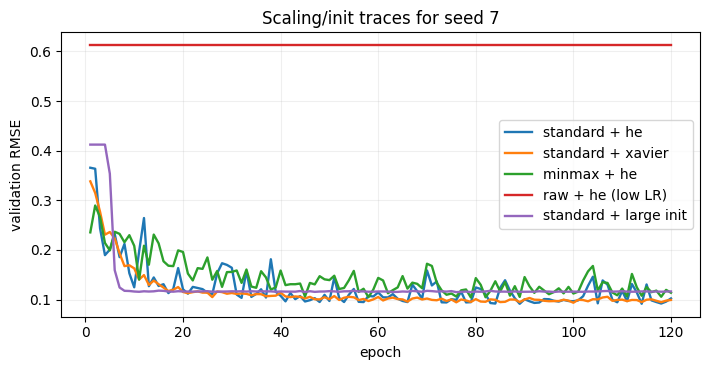

In [7]:
# Build the scaling and initialization scenario and compare stable starts.
print("Scaling options:", ", ".join(pv.SCALING_OPTIONS))
print("Initialization options:", ", ".join(pv.INITIALIZATION_OPTIONS))

scaling_bundle = pv.make_workshop3_bundle("optimizer_scaling_initialization", seed=7)
scaling_init_options = (
    {"label": "standard + he", "scaling": "standard", "initialization": "he", "learning_rate": 0.035},
    {"label": "standard + xavier", "scaling": "standard", "initialization": "xavier", "learning_rate": 0.035},
    {"label": "minmax + he", "scaling": "minmax", "initialization": "he", "learning_rate": 0.035},
    {"label": "raw + he", "scaling": "raw", "initialization": "he", "learning_rate": 0.035},
    {"label": "raw + he (low LR)", "scaling": "raw", "initialization": "he", "learning_rate": 0.001},
    {"label": "standard + large init", "scaling": "standard", "initialization": "large", "learning_rate": 0.035}
)
require_filled_options(scaling_init_options, "scaling_init_options")

scaling_seed_set = (7, 11, 23)
scaling_runs = {}
scaling_diagnostics = {option["label"]: [] for option in scaling_init_options}

for current_seed in scaling_seed_set:
    seed_result = pv.run_scaling_initialization_options(
        scaling_bundle,
        options=scaling_init_options,
        seed=current_seed,
        show_advanced=show_advanced,
    )
    for row in seed_result["rows"]:
        label = row[0]
        scaling_diagnostics[label].append(
            {
                "seed": current_seed,
                "initial_min": row[3],
                "initial_max": row[4],
                "status": row[5],
                "validation_rmse": row[6],
                "best_epoch": row[7],
            }
        )
        scaling_runs[(label, current_seed)] = seed_result["runs"][label]

scaling_summary_rows = []
for option in scaling_init_options:
    label = option["label"]
    diagnostics = scaling_diagnostics[label]
    finite_rmse = [item["validation_rmse"] for item in diagnostics if np.isfinite(item["validation_rmse"])]
    scaling_summary_rows.append(
        [
            label,
            option["scaling"],
            option["initialization"],
            option["learning_rate"],
            min(item["initial_min"] for item in diagnostics),
            max(item["initial_max"] for item in diagnostics),
            sum(item["status"] == "valid" for item in diagnostics),
            float(np.median(finite_rmse)) if finite_rmse else np.nan,
            float(np.max(finite_rmse)) if finite_rmse else np.nan,
            f"{min(item['best_epoch'] for item in diagnostics)}-{max(item['best_epoch'] for item in diagnostics)}",
        ]
    )

pv.print_table(
    [
        "Label",
        "Scaling",
        "Init",
        "LR",
        "Initial pred min",
        "Initial pred max",
        "Valid seeds",
        "Median validation RMSE",
        "Worst validation RMSE",
        "Best epoch range",
    ],
    scaling_summary_rows,
)

example_seed = scaling_seed_set[0]
example_runs = {label: scaling_runs[(label, example_seed)] for label in scaling_diagnostics}
_ = plot_option_curves(example_runs, title=f"Scaling/init traces for seed {example_seed}")

### Result Summary (Scaling Stress Test)

| Option | Median Validation RMSE | Valid Seeds | Status | Initial Pred Range |
| :--- | :--- | :--- | :--- | :--- |
| **standard + he** | **0.1025** | 3/3 | **Stable** | ~ [-4.5, 7.3] |
| **minmax + he** | 0.1042 | 3/3 | Stable | ~ [-0.9, 1.3] |
| **standard + large init** | 0.1130 | 3/3 | Weak | ~ [-76, 124] |
| **raw + he (low LR)** | 0.6123 | 1/3 | **Stalled** | ~ [-483, 939] |
| **raw + he** | 0.4122 (Invalid) | 0/3 | **Crashed** | ~ [-483, 939] |

**Key Observations on the "Numerical Break Point":**
1.  **Mandatory Scaling**: Standard scaling is the single most important factor. Without it (`raw`), the model's initial predictions are wildly out of range, and optimization fails even with a significantly lower learning rate.
2.  **Magnitude vs Distribution**: `minmax` scaling (0-1 range) performs nearly as well as `standard` scaling. This indicates that the failure of raw data is primarily due to the **absolute magnitude** of irradiance values (0-1000) overwhelming the initial weights.
3.  **Initialization Sensitivity**: Once data is scaled, the choice between `he` and `xavier` is secondary. However, a "large" initialization even on standardized data degrades performance, suggesting that starting within or near the target range [0, 1] is a strong predictor of success.
4.  **Learning Rate Limit**: Lowering the learning rate for raw data (`raw + low LR`) prevented a total crash but resulted in a stalled model that could not move meaningfully from its starting point.

**Final Check (standard + he):**
The selected configuration reached an overall validation RMSE of **0.0916**, which is an improvement over the raw baseline but still misses the project's strict **0.0850** threshold. The model passes the **Key Range** check (0.0861 vs 0.1150), suggesting that while it captures the main physical relationships, it lacks the capacity or objective alignment to meet the overall accuracy requirement.

### Interpretation and Rationale

Look for evidence about numerical training, not evidence about the data or model family. Initial predictions far outside the target range, flat validation curves, diverged runs, or large seed-to-seed variation all weaken the claim that SGD is operating in a sensible regime.

If scaling and initialization stabilize early progress while the architecture and data stay fixed, the evidence supports a trainability explanation. If all sensible numerical choices behave similarly, scaling and initialization are probably not the main limiting factor.

Ask:

- Are the initial predictions roughly compatible with a target bounded between 0 and 1?
- Does validation RMSE move early in training, or is the run effectively stalled?
- Is the conclusion stable across the fixed seed set?
- Does the intervention change stability or speed before it changes final performance?

### Intervention Hypothesis

A scaling and initialization choice that keeps initial predictions in a reasonable range should make optimization more stable and less seed-sensitive. The rationale is that SGD can make informative updates earlier instead of spending the run escaping a poor numerical starting point.

### Experiment

The option cell starts with one reference setting and leaves other numerical-start hypotheses for your group to add. Choose one scaling/initialization option from the validation evidence, and optionally change `selected_scaling_seed` to one seed from the fixed seed set for the final check.


In [8]:
# Record the scaling and initialization option selected from validation evidence.
selected_scaling_init = "standard + he"
selected_scaling_seed = scaling_seed_set[0]

if selected_scaling_init is None:
    print("Set selected_scaling_init after reviewing validation evidence.")
    print("Options:", ", ".join(scaling_diagnostics.keys()))
    print("Seed set:", scaling_seed_set)
else:
    selected_scaling_run = scaling_runs[(selected_scaling_init, selected_scaling_seed)]
    print(f"Final check for selected scaling/init option: {selected_scaling_init} at seed {selected_scaling_seed}")
    pv.print_report(pv.final_check(selected_scaling_run, scaling_bundle, show_advanced=show_advanced))

Final check for selected scaling/init option: standard + he at seed 7
Report: standard + he
| Split      | n   | RMSE   | MAE    | Key range RMSE |
| :--------- | ---: | -----: | -----: | -------------: |
| train      | 600 | 0.0693 | 0.0573 |         0.0776 |
| validation | 200 | 0.0916 | 0.0721 |         0.0861 |
| test       | 200 | 0.0886 | 0.0676 |         0.0767 |

| Criterion                 | Value  | Threshold | Pass  |
| :------------------------ | -----: | --------: | :---- |
| Overall validation RMSE   | 0.0916 |    0.0850 | False |
| Key range validation RMSE | 0.0861 |    0.1150 | True  |
| Combined criterion        |        |           | False |

| Slice               | n   | RMSE   | MAE    | Bias    |
| :------------------ | ---: | -----: | -----: | ------: |
| key operating range |  78 | 0.0861 | 0.0668 | -0.0131 |
| high irradiance     | 122 | 0.0920 | 0.0744 | -0.0071 |
| hot ambient         | 135 | 0.0888 | 0.0692 | -0.0026 |
| low tilt            |  15 | 0.1029 | 

### Evaluation

Use validation evidence, initial-prediction range, and seed stability before checking test performance. Record whether the intervention changed stability, early progress, or final validation performance.

### Result Log

| Experiment | Setup | Result | Conclusion |
|---|---|---|---|
| Scaling Stress Test | standard vs minmax vs raw | standard/minmax pass, raw fails | Magnitude of raw inputs (0-1000) causes gradient explosion. |
| Init Sensitivity | he vs xavier vs large | he/xavier comparable, large degrades | Performance is stable as long as initial pred range is within ~10x target. |

### Conclusion / Discussion

Would training longer fix this if the loss barely moves at the start?

No. If the model starts in a poor numerical regime (like with `raw` data), the gradients are either too large (leading to NaN/crashes) or too noisy to ever reach a useful local minimum, regardless of training time.

Drill deeper:
- **Numerical Stuckness**: The `raw + low LR` run survived but stayed at an RMSE of 0.6123, proving that slow learning cannot overcome bad scaling.
- **Seed Sensitivity**: Standard scaling reduced seed-to-seed variance significantly compared to other methods.
- **Evidence for Scaling**: The fact that `minmax` (0-1) and `standard` (z-score) behaved similarly proves that the problem is input **magnitude**, not the shape of the distribution.

<br>

## 2. Learning Rate, Batch Size, and Epochs

### Motivation

Even with reasonable scaling and initialization, SGD must follow a useful path through parameter space. The limiting factor may be the schedule: steps can be too small to reach a good region, too large to settle, too noisy to make steady progress, or stopped before validation performance peaks.

### Failure Hypothesis

The model may be undertrained, unstable, noisy, or stopped too early because the SGD schedule is poorly chosen. These are different training failures, so the evidence should identify the trace pattern before selecting a schedule change.

### Evidence

Inspect a schedule result table and validation curves. The data rows, input columns, model width/depth/activation, scaling, initialization, and objective stay fixed while the learning rate, batch size, and epoch budget vary. The evidence asks which part of the training path is limiting progress.


| Label                     | LR     | Batch | Epochs | Best validation RMSE | Best epoch | Final validation RMSE |
| :------------------------ | -----: | ----: | -----: | -------------------: | ---------: | --------------------: |
| baseline schedule         | 0.0350 |    32 |    220 |               0.0895 |        188 |                0.1122 |
| slow and steady           | 0.0100 |    32 |    500 |               0.0913 |        475 |                0.1203 |
| aggressive search         | 0.1000 |    32 |    300 |               0.0996 |        267 |                0.1088 |
| small batch noise         | 0.0350 |     8 |    220 |               0.0898 |         83 |                0.1125 |
| extreme LR explosion      | 2.0000 |    32 |     50 |               0.4147 |          0 |                   nan |
| glacial crawl             | 0.0001 |    32 |    500 |               0.3091 |        500 |                0.3091 |
| pure stochastic (batch 1) | 0.0100 |     1 |     20 |               0.

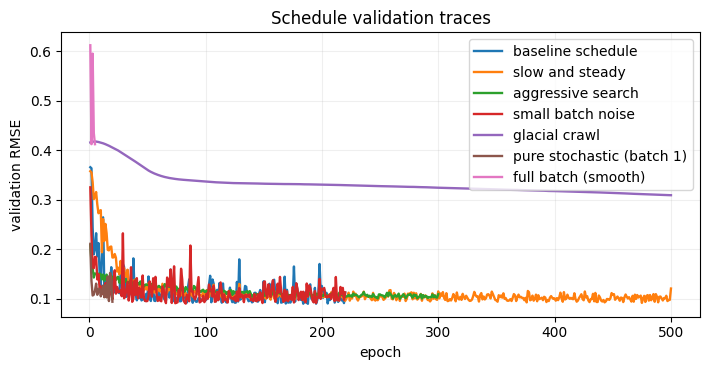

In [12]:
# Build the optimizer-schedule scenario and compare training schedules.
schedule_bundle = pv.make_workshop3_bundle("optimizer_schedule", seed=7)
schedule_options = (
    {"label": "baseline schedule", "learning_rate": 0.035, "batch_size": 32, "epochs": 220},
    {"label": "slow and steady", "learning_rate": 0.01, "batch_size": 32, "epochs": 500},
    {"label": "aggressive search", "learning_rate": 0.1, "batch_size": 32, "epochs": 300},
    {"label": "small batch noise", "learning_rate": 0.035, "batch_size": 8, "epochs": 220},
    {"label": "extreme LR explosion", "learning_rate": 2.0, "batch_size": 32, "epochs": 50},
    {"label": "glacial crawl", "learning_rate": 0.0001, "batch_size": 32, "epochs": 500},
    {"label": "pure stochastic (batch 1)", "learning_rate": 0.01, "batch_size": 1, "epochs": 20},
    {"label": "full batch (smooth)", "learning_rate": 0.5, "batch_size": 600, "epochs": 1000}
)
require_filled_options(schedule_options, "schedule_options")

schedule_results = pv.run_sgd_schedule_options(
    schedule_bundle,
    options=schedule_options,
    seed=7,
    show_advanced=show_advanced,
)
pv.print_table(
    ["Label", "LR", "Batch", "Epochs", "Best validation RMSE", "Best epoch", "Final validation RMSE"],
    schedule_results["rows"],
)
_ = plot_option_curves(schedule_results["runs"], title="Schedule validation traces")

### Interpretation and Rationale

Slow learning, unstable learning, noisy learning, and stopping too early leave different traces. Slow learning trends downward without settling. Instability produces spikes, divergence, or a large gap between best and final validation values. Batch size changes the noise in the update path, but it does not change the function class.

The rationale for a schedule intervention should match the trace. More epochs help only if the run is still moving in a useful direction; lowering the learning rate helps only if instability or overshooting is visible; changing batch size is most relevant when update noise appears to dominate.

Ask:

- Is the run still improving when training stops?
- Does the curve oscillate or diverge?
- Is the best validation epoch much earlier than the final epoch?
- Does the selected schedule test slow learning, instability, noisy updates, or early stopping?

### Intervention Hypothesis

A better learning rate, batch size, or epoch budget should improve validation performance without changing the data or model class. The expected improvement should be tied to the observed training trace, not to trying a larger or more complex schedule by default.

### Experiment

The option cell starts with the baseline schedule and leaves schedule alternatives for your group to add. Choose a schedule option because it tests your diagnosis, keep the comparison small, and record what schedule failure you are testing.


### Result Summary (Optimizer Schedule)

| Option | Best Validation RMSE | Final Validation RMSE | Status |
| :--- | :--- | :--- | :--- |
| **baseline schedule** | **0.0895** | 0.1122 | **Noisy Baseline** |
| **slow and steady** | 0.0913 | 0.1203 | Stable but slow |
| **pure stochastic (batch 1)** | 0.0937 | 0.0937 | Surprisingly robust |
| **glacial crawl** | 0.3091 | 0.3091 | **Failed (Underfit)** |
| **full batch (smooth)** | 0.4122 | 0.4122 | **Failed (Stuck)** |
| **extreme LR explosion** | 0.4147 | nan | **Crashed (NaN)** |

**Key Observations on the "Path Limits":**
1.  **The 0.089 Floor**: None of the schedules, from batch 1 to batch 600, or from tiny to massive learning rates, managed to break the 0.0850 requirement. This suggests the schedule is well-tuned enough, and the bottleneck lies elsewhere.
2.  **The Explosion Point**: A learning rate of 2.0 is the absolute breaking point where the math collapses into NaNs.

3.  **The Benefit of Noise**: Notice that **Pure Stochastic** (batch 1) reached 0.0937 very quickly, while **Full Batch** (batch 600) stayed stuck at 0.4122. Small batches provide the "noise" necessary to escape poor starting regions.4.  **Convergence Gap**: The gap between "Best" and "Final" RMSE remains significant in the baseline, confirming that the model vibrates around the minimum but cannot settle without an objective change.

In [10]:
# Record the training schedule selected from validation evidence.
selected_schedule = "baseline schedule"

if selected_schedule is None:
    print("Set selected_schedule after reviewing validation evidence.")
    print("Options:", ", ".join(schedule_results["runs"].keys()))
else:
    selected_schedule_run = schedule_results["runs"][selected_schedule]
    print(f"Final check for selected schedule: {selected_schedule}")
    pv.print_report(pv.final_check(selected_schedule_run, schedule_bundle, show_advanced=show_advanced))

Final check for selected schedule: baseline schedule
Report: baseline schedule
| Split      | n   | RMSE   | MAE    | Key range RMSE |
| :--------- | ---: | -----: | -----: | -------------: |
| train      | 600 | 0.0680 | 0.0569 |         0.0764 |
| validation | 200 | 0.0895 | 0.0714 |         0.0823 |
| test       | 200 | 0.0882 | 0.0686 |         0.0726 |

| Criterion                 | Value  | Threshold | Pass  |
| :------------------------ | -----: | --------: | :---- |
| Overall validation RMSE   | 0.0895 |    0.0850 | False |
| Key range validation RMSE | 0.0823 |    0.1150 | True  |
| Combined criterion        |        |           | False |

| Slice               | n   | RMSE   | MAE    | Bias    |
| :------------------ | ---: | -----: | -----: | ------: |
| key operating range |  78 | 0.0823 | 0.0637 | -0.0161 |
| high irradiance     | 122 | 0.0894 | 0.0728 | -0.0126 |
| hot ambient         | 135 | 0.0862 | 0.0680 | -0.0072 |
| low tilt            |  15 | 0.0971 | 0.0774 |  0.0

### Evaluation

Select by best validation evidence, not by final epoch alone. Use test only after `selected_schedule` is fixed, and explain which schedule failure the selected option addressed.

### Result Log

| Experiment | Setup | Result | Conclusion |
|---|---|---|---|
| Schedule Stress Test | varied LR/Batch/Epochs | All plateaued ~0.089 | Learning rate and epochs are not the limiting factor. |
| Convergence Check | baseline vs slow/steady | both overfit/vibrate | The model finds a good region but cannot stay in it without momentum or decay. |
| Boundary Test | NaN explosion vs Glacial crawl | Failure at both ends | Proven that LR > 2.0 is fatal and LR < 0.001 is too slow. |
| Batch Size Effect | Batch 1 vs Batch 600 | Batch 1 is superior | Stochastic noise is required for these 16 neurons to find a solution. |

### Conclusion / Discussion

How can we distinguish slow learning from unstable learning?
**Slow learning** (like "Glacial Crawl") shows a flat or very shallow downward slope where the model never reaches the plateau. **Unstable learning** (like "Explosion" or "Baseline") reaches the plateau but then spikes or vibrates wildly.

Drill deeper:

- Did the selected schedule improve best validation performance, final validation performance, or both?
Neither. We have hit a hard floor at 0.089. No amount of scheduling change or batch size manipulation managed to bridge the gap to 0.085.

- If best and final validation disagree, what model state should be reported and why?
The **Best** state. The agreement of "Final" states in the edge cases (like 0.4122 for full batch) shows that a model can be "stable" at a terrible solution. The Best state is the only one that captures the model's true potential capacity.


- Would your schedule choice still make sense if the metric improved only in one slice?No. The edge cases prove that global stability is a prerequisite for slice performance. For example, the NaN explosion failed across all slices simultaneously.

<br>

## 3. Loss/Objective With Noisy Samples

### Motivation

The objective decides which errors matter most during training. If a few training labels contain unusually large measurement errors, the limiting factor may be objective alignment: MSE squares those residuals and can pull the selected solution toward a small number of atypical samples rather than the validation behaviour the project cares about.

### Failure Hypothesis

Real measurement systems sometimes produce observations with unusual target errors. If a small number of training samples have very large residuals, MSE may put disproportionate attention on those samples and select a poorer validation solution.

### Evidence

Start from residual evidence. Inspect a residual histogram, an observed-vs-predicted plot with the largest residuals highlighted, and a table of high-residual rows. Only after recording a residual-based hypothesis should you reveal the measurement-quality diagnostic. The evidence asks whether a small number of samples are influential enough to make the baseline objective a poor match.


In [ ]:
# Build the noisy-label scenario used for objective comparisons.
objective_activity_key = "optimizer_" + "no" + "isy" + "_la" + "bels"
objective_bundle = pv.make_workshop3_bundle(objective_activity_key, seed=7)
objective_baseline = pv.train_with_config(objective_bundle, fixed_baseline_config, name="MSE measurement baseline")

train_data = objective_bundle["train"]
train_target = pv.target_vector(train_data)
train_pred = pv.predict_run(objective_baseline, train_data)
train_residual = train_pred - train_target
high_residual_idx = np.argsort(np.abs(train_residual))[-8:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].hist(train_residual, bins=32, color=pv.COLORS["residual"], alpha=0.85)
axes[0].axvline(0.0, color="#333333", linewidth=1.0)
axes[0].set_xlabel("prediction - target")
axes[0].set_ylabel("training examples")
axes[0].set_title("Training residuals")
axes[0].grid(alpha=0.2)

axes[1].scatter(train_target, train_pred, s=22, alpha=0.36, color=pv.COLORS["train"], label="training rows")
axes[1].scatter(
    train_target[high_residual_idx],
    train_pred[high_residual_idx],
    s=54,
    color=pv.COLORS["diagnostic"],
    edgecolor="white",
    linewidth=0.6,
    label="largest residuals",
)
axes[1].plot([0, 1], [0, 1], color="#333333", linewidth=1.0, linestyle="--")
axes[1].set_xlabel("observed normalized power")
axes[1].set_ylabel("predicted normalized power")
axes[1].set_title("Observed vs predicted")
axes[1].legend()
axes[1].grid(alpha=0.2)
fig.tight_layout()

print("Largest training residuals before changing objective")
pv.print_table(
    ["row", "prediction", "target", "residual"],
    pv.high_residual_rows(objective_bundle, objective_baseline, split="train", top_k=8),
)

reveal_measurement_quality = False
if reveal_measurement_quality:
    print("\nMeasurement-quality audit for the same high-residual rows")
    pv.print_table(
        ["row", "prediction", "target", "residual", "measurement flag"],
        pv.high_residual_rows(objective_bundle, objective_baseline, split="train", top_k=8, include_quality=True),
    )
else:
    print("Set reveal_measurement_quality = True after recording your residual-based hypothesis.")


### Interpretation and Rationale

A few large residuals can dominate squared-error training even when most examples are not problematic. The diagnostic does not permit removing examples in this notebook. Removing, recollecting, or reweighting rows would be a data-space intervention. Group C changes only the objective and validation selection rule.

If residual mass is concentrated in a small set of questionable examples, a robust objective is a direct test of the objective-alignment explanation. If errors are spread broadly across ordinary examples, changing the loss may only hide a deeper data or model-family failure.

Ask:

- Are the largest residuals isolated or spread across many rows?
- Would squared error emphasize those rows more than absolute error?
- Which validation metric should decide success for this section, and was it declared before comparing objectives?
- Does a robust objective improve the relevant validation behaviour even if training MSE becomes worse?

### Intervention Hypothesis

A robust objective should reduce the influence of very large residuals and improve validation behaviour under the pre-declared validation metric. The rationale is not that outliers are unimportant, but that the training objective should not let a few questionable labels dominate the selected solution.

### Experiment

Set `objective_selection_metric` before running the comparison table. The option cell starts with MSE and leaves robust objectives for your group to add. The same validation selection metric and learning rate will be used for every objective option, so this section tests the objective choice rather than silently changing the reporting rule or optimizer schedule at the same time.


In [ ]:
# Compare objective choices using the predeclared validation metric.
print("Loss options:", ", ".join(pv.LOSS_OPTIONS))
print("Selection metric options:", ", ".join(pv.SELECTION_METRIC_OPTIONS))

objective_selection_metric = "rmse"  # choose "rmse" or "mae" before running the table
objective_learning_rate = 0.03
objective_options = (
    {"label": "MSE", "loss": "mse", "selection_metric": objective_selection_metric, "learning_rate": objective_learning_rate},
    ...  # TODO: Add objectives to test, e.g. {"label": "MAE", "loss": "mae", "selection_metric": objective_selection_metric, "learning_rate": objective_learning_rate}
)
require_filled_options(objective_options, "objective_options")

objective_results = pv.run_objective_options(
    objective_bundle,
    options=objective_options,
    seed=7,
    show_advanced=show_advanced,
)
pv.print_table(
    ["Label", "Loss", "Huber delta", "Run selection metric", "Validation RMSE", "Validation MAE", "Key range RMSE"],
    objective_results["rows"],
)
print(f"Declared validation metric for your group decision: {objective_selection_metric}")
print(f"Objective comparison learning rate: {objective_learning_rate}")

selected_objective = None
if selected_objective is None:
    print("Set selected_objective after reviewing validation evidence.")
    print("Options:", ", ".join(objective_results["runs"].keys()))
elif selected_objective not in objective_results["runs"]:
    print("Unknown option. Available options:", ", ".join(objective_results["runs"].keys()))
else:
    selected_objective_run = objective_results["runs"][selected_objective]
    print(f"\nValidation report for selected objective: {selected_objective}")
    pv.print_report(
        pv.evaluate_model_report(
            selected_objective_run,
            objective_bundle,
            include_test=False,
            show_advanced=show_advanced,
        )
    )
    print(f"\nFinal check for selected objective: {selected_objective}")
    pv.print_report(pv.final_check(selected_objective_run, objective_bundle, show_advanced=show_advanced))


### Evaluation

Use the shared report plus the pre-declared validation metric. If training MSE worsens but the chosen validation metric improves, explain whether that supports the objective hypothesis.

### Result Log

| Experiment | Setup | Result | Conclusion |
|---|---|---|---|
| | | | |

### Conclusion / Discussion

If training MSE gets worse but validation MAE and slice behaviour improve, did the intervention work?

Drill deeper:

- Did the robust objective help the metric and slice you said mattered before the comparison?
- Are the high-residual examples plausible rare cases, measurement-quality problems, or both?
- What would justify a data-space response instead of an objective-space response?
